# Talep Tahmini ve Stok Politikası Karşılaştırması

Stok politikasının kalitesi büyük ölçüde **talep tahmininin kalitesine** bağlıdır. Bu notebook'ta:

1. Günlük talep verisi için dört tahmin yöntemi kurulur: **hareketli ortalama, üstel düzeltme, mevsimsel naive, Holt-Winters**
2. Yöntemler **hata ölçütleriyle** (MAE, RMSE, MAPE) karşılaştırılır
3. Her tahmin, **periyodik gözden geçirmeli (R, S) stok politikasına** girdi olur ve simülasyonla maliyet / hizmet düzeyi karşılaştırılır

> ⚠️ **Veri hakkında:** Aşağıdaki hücre `talep.csv` dosyası varsa onu okur. Dosya yoksa **üretilmiş örnek veri** kullanır.
> Gerçek veriyle çalıştırmak için bkz. [Gerçek veri kullanmak](#gerçek-veri-kullanmak).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from itertools import product
from statistics import NormalDist

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})

## Veri

Beklenen format: `talep.csv` dosyasında iki sütun, **`tarih`** ve **`talep`** (günlük satış adedi).

Kullanılan veri: ÜRETİLMİŞ örnek veri  |  730 gün  |  2024-01-01 → 2025-12-30
Eğitim: 550 gün, Test: 180 gün


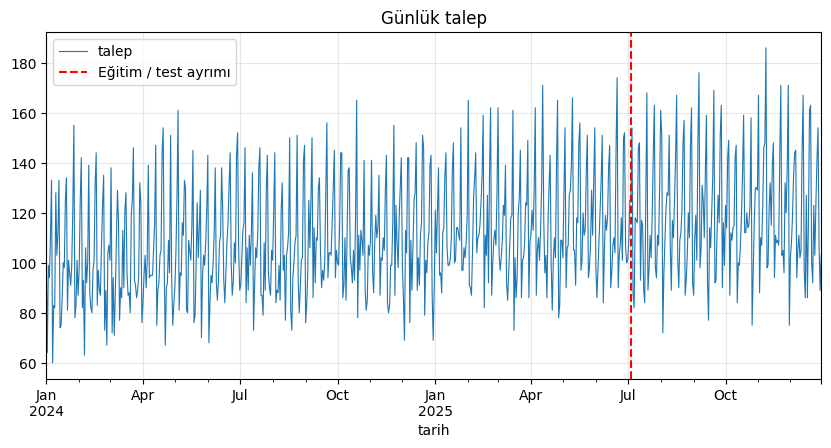

In [2]:
VERI_DOSYASI = "talep.csv"

if os.path.exists(VERI_DOSYASI):
    df = pd.read_csv(VERI_DOSYASI, parse_dates=["tarih"]).sort_values("tarih").reset_index(drop=True)
    kaynak = "GERÇEK veri"
else:
    rng = np.random.default_rng(3)
    n = 730
    t = np.arange(n)
    hafta = np.array([0.85, 0.90, 0.95, 1.00, 1.15, 1.35, 0.80])
    hafta = hafta / hafta.mean()                                  # haftalık desen
    seviye = 100 + 0.03 * t                                       # hafif artan trend
    talep = seviye * hafta[t % 7] + rng.normal(0, 10, n)
    df = pd.DataFrame({"tarih": pd.date_range("2024-01-01", periods=n),
                       "talep": np.maximum(0, talep).round()})
    kaynak = "ÜRETİLMİŞ örnek veri"

print(f"Kullanılan veri: {kaynak}  |  {len(df)} gün  |  {df['tarih'].min().date()} → {df['tarih'].max().date()}")

y = df["talep"].to_numpy(dtype=float)
N_TEST = 180
n_train = len(y) - N_TEST
print(f"Eğitim: {n_train} gün, Test: {N_TEST} gün")

df.set_index("tarih")["talep"].plot(lw=0.8, title="Günlük talep")
plt.axvline(df["tarih"].iloc[n_train], color="red", ls="--", label="Eğitim / test ayrımı")
plt.legend(); plt.show()

## 1. Tahmin yöntemleri

Her yöntem iki işlev sunar: `update(y)` yeni gözlemi işler, `forecast(H)` sonraki $H$ günü tahmin eder.

| Yöntem | Fikir |
|---|---|
| Hareketli ortalama (MA) | Son $k$ günün ortalaması |
| Üstel düzeltme (SES) | Yeni gözleme $\alpha$, geçmişe $1-\alpha$ ağırlık |
| Mevsimsel naive | Tahmin = bir hafta önceki aynı günün değeri |
| Holt-Winters (toplamsal) | Seviye + trend + haftalık mevsimsellik |

In [3]:
class MA:
    def __init__(self, k=7): self.k, self.h = k, []
    def update(self, y): self.h.append(y)
    def forecast(self, H): return np.full(H, np.mean(self.h[-self.k:]) if self.h else 0.0)

class SES:
    def __init__(self, alpha): self.a, self.l = alpha, None
    def update(self, y): self.l = y if self.l is None else self.a * y + (1 - self.a) * self.l
    def forecast(self, H): return np.full(H, 0.0 if self.l is None else self.l)

class SeasonalNaive:
    def __init__(self, m=7): self.m, self.h = m, []
    def update(self, y): self.h.append(y)
    def forecast(self, H):
        if len(self.h) < self.m: return np.full(H, np.mean(self.h) if self.h else 0.0)
        return np.array([self.h[-self.m + (k % self.m)] for k in range(H)])

class HoltWinters:
    def __init__(self, a, b, g, m=7):
        self.a, self.b, self.g, self.m = a, b, g, m
        self.l = None; self.bt = 0.0; self.s = None; self.t = 0; self.buf = []
    def update(self, y):
        if self.l is None:                                   # ilk m gözlemle başlat
            self.buf.append(y)
            if len(self.buf) == self.m:
                self.l = float(np.mean(self.buf))
                self.s = list(np.array(self.buf) - self.l)
                self.t = self.m
            return
        i = self.t % self.m
        l_prev = self.l
        self.l = self.a * (y - self.s[i]) + (1 - self.a) * (self.l + self.bt)
        self.bt = self.b * (self.l - l_prev) + (1 - self.b) * self.bt
        self.s[i] = self.g * (y - self.l) + (1 - self.g) * self.s[i]
        self.t += 1
    def forecast(self, H):
        if self.l is None: return np.full(H, np.mean(self.buf) if self.buf else 0.0)
        return np.array([self.l + (k + 1) * self.bt + self.s[(self.t + k) % self.m] for k in range(H)])

### Parametre seçimi

SES ve Holt-Winters parametreleri **yalnızca eğitim verisi** üzerinde, bir adım ilerideki tahmin hatasını (MAE) en aza indirecek şekilde seçilir.
Test verisi parametre seçiminde kullanılmaz.

In [4]:
def one_step_predictions(make, y):
    m, preds = make(), np.zeros(len(y))
    for t, v in enumerate(y):
        preds[t] = m.forecast(1)[0]
        m.update(v)
    return preds

WARM = 14      # ilk 2 hafta ısınma dönemi, hata hesabına katılmaz

def train_mae(make):
    p = one_step_predictions(make, y[:n_train])
    return np.mean(np.abs(y[WARM:n_train] - p[WARM:]))

# SES
en_iyi_ses = min(((train_mae(lambda a=a: SES(a)), a) for a in [0.05, 0.1, 0.2, 0.3, 0.5]))
# Holt-Winters
grid = list(product([0.05, 0.1, 0.2, 0.3], [0.0, 0.01, 0.05], [0.05, 0.1, 0.2, 0.3]))
en_iyi_hw = min(((train_mae(lambda p=p: HoltWinters(*p)), p) for p in grid))

print(f"SES en iyi alpha            : {en_iyi_ses[1]}  (eğitim MAE = {en_iyi_ses[0]:.2f})")
print(f"Holt-Winters en iyi (α,β,γ) : {en_iyi_hw[1]}  (eğitim MAE = {en_iyi_hw[0]:.2f})")

SES en iyi alpha            : 0.05  (eğitim MAE = 17.53)
Holt-Winters en iyi (α,β,γ) : (0.05, 0.0, 0.2)  (eğitim MAE = 8.36)


In [5]:
yontemler = {
    "Hareketli ort. (7 gün)": lambda: MA(7),
    "Üstel düzeltme (SES)":   lambda: SES(en_iyi_ses[1]),
    "Mevsimsel naive":        lambda: SeasonalNaive(7),
    "Holt-Winters":           lambda: HoltWinters(*en_iyi_hw[1]),
}

tahmin = {ad: one_step_predictions(f, y) for ad, f in yontemler.items()}

def metrikler(gercek, tah):
    e = gercek - tah
    return {"MAE": np.mean(np.abs(e)), "RMSE": sqrt(np.mean(e ** 2)),
            "MAPE (%)": np.mean(np.abs(e) / np.maximum(gercek, 1)) * 100}

y_test = y[n_train:]
tablo = pd.DataFrame({ad: metrikler(y_test, p[n_train:]) for ad, p in tahmin.items()}).T.round(2)
tablo.sort_values("MAE")

,MAE,RMSE,MAPE (%)
Holt-Winters,8.78,11.13,7.73
Mevsimsel naive,11.51,14.45,10.15
Hareketli ort. (7 gün),20.07,24.69,17.31
Üstel düzeltme (SES),20.40,24.95,17.61


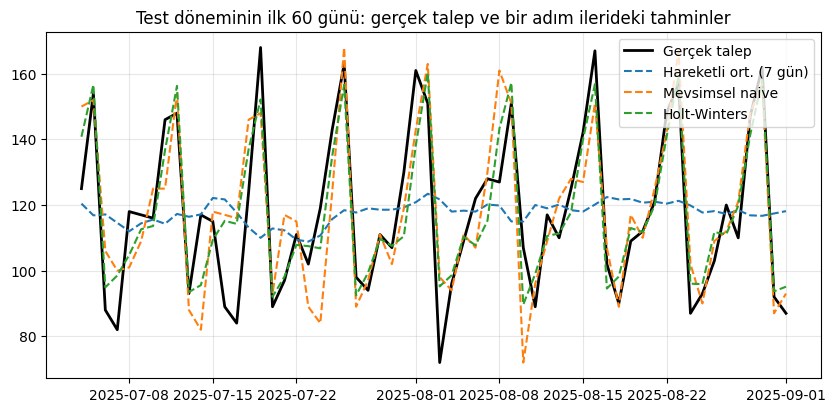

In [6]:
son = 60
x = df["tarih"].iloc[n_train:n_train + son]
plt.plot(x, y_test[:son], "k-", lw=2, label="Gerçek talep")
for ad in ["Hareketli ort. (7 gün)", "Mevsimsel naive", "Holt-Winters"]:
    plt.plot(x, tahmin[ad][n_train:n_train + son], "--", label=ad)
plt.title("Test döneminin ilk 60 günü: gerçek talep ve bir adım ilerideki tahminler")
plt.legend(); plt.show()

## 2. Tahminleri stok politikasına bağlamak

**Periyodik gözden geçirmeli (R, S) politikası:** Her $R$ günde bir stok sayılır ve **hedef stok seviyesi $S$'e tamamlanacak kadar** sipariş verilir.
Sipariş $L$ gün sonra gelir. Koruma süresi $H = R + L$ gündür:

$$S = \underbrace{\sum_{k=1}^{H} \hat d_{t+k}}_{\text{tahmini talep}} + \underbrace{z \cdot \sigma_e \sqrt{H}}_{\text{emniyet stoğu}}$$

- $\hat d$: yöntemin tahmini, $\sigma_e$: eğitim döneminde bir adım tahmin hatasının standart sapması
- Tahmin ne kadar iyiyse $\sigma_e$ o kadar küçük, dolayısıyla emniyet stoğu ve maliyet o kadar düşük olur
- **Karşılaştırma tabanı:** tahmin kullanmayan, sabit ortalama talebe göre çalışan politika
- **Varsayılan parametreler:** $R = 1$ (günlük gözden geçirme), $L = 3$ gün, sipariş başına sabit maliyet $K = 10$, günlük birim elde tutma maliyeti $0{,}05$, eksik stok cezası $4$/birim (kayıp satış)

> Basitleştirme: $H$ günlük toplam hatanın $\sigma_e\sqrt{H}$ olduğu, yani günlük hataların bağımsız olduğu varsayılır.

In [7]:
class Sabit:
    """Tahmin kullanmayan taban: eğitim ortalamasını sabit tahmin olarak kullanır."""
    def __init__(self, ort): self.ort = ort
    def update(self, y): pass
    def forecast(self, H): return np.full(H, self.ort)

def simulate_RS(y_test, model, sigma_e, L=3, R=1, z=1.645, h=0.05, K=10.0, pen=4.0):
    on_hand = float(np.sum(model.forecast(R + L)))            # başlangıç stoğu
    pipeline = {}                                             # varış günü -> miktar
    hold = order = short = unmet = total = 0.0
    n_orders = 0
    stok = []
    for t, d in enumerate(y_test):
        on_hand += pipeline.pop(t, 0.0)
        total += d
        sold = min(on_hand, d); on_hand -= sold
        lost = d - sold; unmet += lost
        short += pen * lost; hold += h * on_hand
        stok.append(on_hand)
        model.update(d)
        if t % R == 0:
            H = R + L
            S = model.forecast(H).sum() + z * sigma_e * sqrt(H)
            pos = on_hand + sum(pipeline.values())
            q = max(0.0, S - pos)
            if q > 0:
                pipeline[t + L + 1] = pipeline.get(t + L + 1, 0.0) + q
                order += K; n_orders += 1
    gun = len(y_test)
    return {"günlük maliyet": (hold + order + short) / gun,
            "elde tutma": hold / gun, "sipariş": order / gun, "eksik stok": short / gun,
            "fill rate (%)": (1 - unmet / total) * 100,
            "ort. stok": float(np.mean(stok)), "sipariş sayısı": n_orders}

def hazirla(ad):
    """Modeli eğitim verisiyle ısıtır ve eğitim hatasının std'sini döndürür."""
    if ad == "Tahminsiz (sabit ortalama)":
        return Sabit(y[:n_train].mean()), float(np.std(y[:n_train]))
    m = yontemler[ad]()
    for v in y[:n_train]: m.update(v)
    e = y[WARM:n_train] - tahmin[ad][WARM:n_train]
    return m, float(np.std(e))

sonuclar = {}
for ad in ["Tahminsiz (sabit ortalama)"] + list(yontemler):
    model, sig = hazirla(ad)
    sonuclar[ad] = {"σ_e": sig, **simulate_RS(y_test, model, sig)}

karsilastirma = pd.DataFrame(sonuclar).T
karsilastirma.round(2).sort_values("günlük maliyet")

,σ_e,günlük maliyet,elde tutma,sipariş,eksik stok,fill rate (%),ort. stok,sipariş sayısı
Holt-Winters,10.53,13.93,1.95,10.0,1.97,99.59,39.08,180.0
Mevsimsel naive,13.56,14.58,2.48,10.0,2.10,99.56,49.57,180.0
Üstel düzeltme (SES),21.84,16.17,3.74,10.0,2.43,99.49,74.82,180.0
Hareketli ort. (7 gün),21.64,16.63,3.79,10.0,2.83,99.41,75.88,180.0
Tahminsiz (sabit ortalama),22.04,28.64,2.39,10.0,16.25,96.60,47.90,180.0


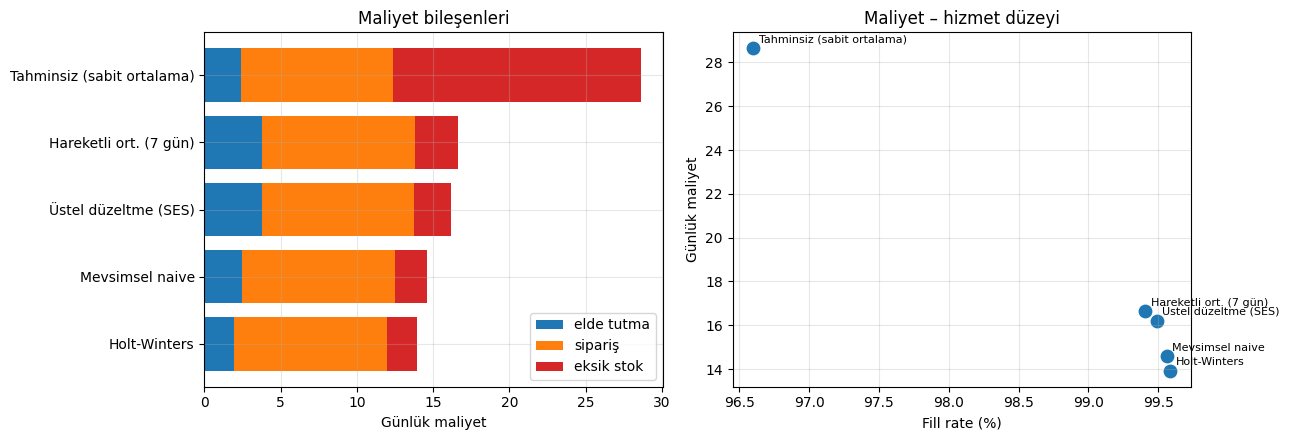

In [8]:
sirali = karsilastirma.sort_values("günlük maliyet")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

alt = np.zeros(len(sirali))
for kol, renk in [("elde tutma", "tab:blue"), ("sipariş", "tab:orange"), ("eksik stok", "tab:red")]:
    ax[0].barh(sirali.index, sirali[kol], left=alt, label=kol, color=renk)
    alt += sirali[kol].values
ax[0].set_xlabel("Günlük maliyet"); ax[0].set_title("Maliyet bileşenleri"); ax[0].legend()

ax[1].scatter(sirali["fill rate (%)"], sirali["günlük maliyet"], s=80)
for ad, r in sirali.iterrows():
    ax[1].annotate(ad, (r["fill rate (%)"], r["günlük maliyet"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].set_xlabel("Fill rate (%)"); ax[1].set_ylabel("Günlük maliyet"); ax[1].set_title("Maliyet – hizmet düzeyi")
plt.tight_layout(); plt.show()

### Adil karşılaştırma: aynı hizmet düzeyinde kim daha az stokla çalışıyor?

Yukarıdaki tablo tek bir emniyet katsayısı ($z = 1{,}645$) içindir. Yöntemler farklı fill rate'lere ulaştığı için
maliyetleri doğrudan kıyaslamak yanıltıcı olabilir. Bu yüzden her yöntemde $z$'yi değiştirip
**ortalama stok – fill rate** eğrisini çiziyoruz. Eğri **sol üste** ne kadar yakınsa, o yöntem aynı hizmeti daha az stokla sağlar.

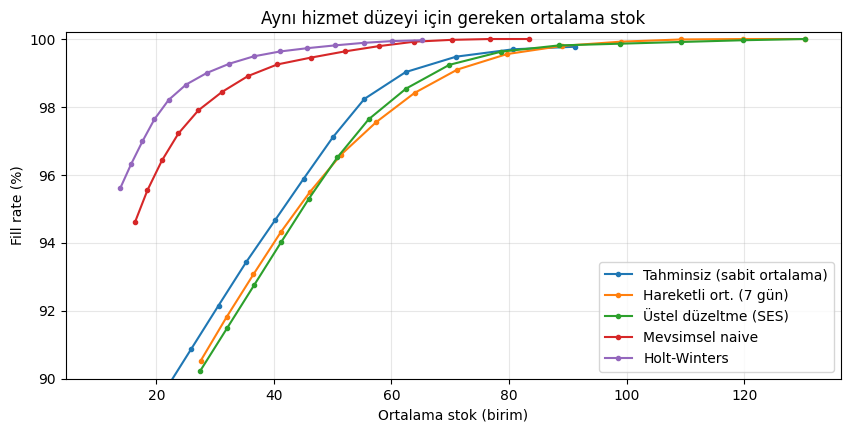

,gereken ort. stok,günlük maliyet (en düşük)
Holt-Winters,28.6,13.3
Mevsimsel naive,40.6,13.6
Tahminsiz (sabit ortalama),62.4,15.5
Üstel düzeltme (SES),69.8,15.3
Hareketli ort. (7 gün),71.2,15.3


In [9]:
zler = np.arange(-0.5, 3.01, 0.25)
egri = {}
for ad in ["Tahminsiz (sabit ortalama)"] + list(yontemler):
    satirlar = []
    for zv in zler:
        model, sig = hazirla(ad)
        r = simulate_RS(y_test, model, sig, z=zv)
        satirlar.append({"z": zv, "ort. stok": r["ort. stok"], "fill rate (%)": r["fill rate (%)"],
                         "günlük maliyet": r["günlük maliyet"]})
    egri[ad] = pd.DataFrame(satirlar)

for ad, e in egri.items():
    plt.plot(e["ort. stok"], e["fill rate (%)"], "o-", ms=3, label=ad)
plt.xlabel("Ortalama stok (birim)"); plt.ylabel("Fill rate (%)"); plt.ylim(90, 100.2)
plt.title("Aynı hizmet düzeyi için gereken ortalama stok"); plt.legend(); plt.show()

HEDEF = 99.0
ozet = {}
for ad, e in egri.items():
    uygun = e[e["fill rate (%)"] >= HEDEF]
    ozet[ad] = {"gereken ort. stok": uygun["ort. stok"].min() if len(uygun) else np.nan,
                "günlük maliyet (en düşük)": uygun["günlük maliyet"].min() if len(uygun) else np.nan}
pd.DataFrame(ozet).T.round(1).sort_values("gereken ort. stok")

### Gözden geçirme periyodunun etkisi

Tahminin değeri, **koruma süresinin** ($R + L$) hangi günlere denk geldiğine de bağlıdır. $R = 7$ gün olduğunda koruma süresi haftalık deseni neredeyse tam kapsar
ve haftalık mevsimsellik büyük ölçüde birbirini götürür; bu durumda tahmin yönteminin farkı azalır. Aşağıda aynı yöntemleri $R = 1$ ve $R = 7$ için karşılaştırıyoruz.

In [10]:
rows = []
for R_ in (1, 7):
    for ad in ["Tahminsiz (sabit ortalama)"] + list(yontemler):
        model, sig = hazirla(ad)
        r = simulate_RS(y_test, model, sig, R=R_, K=10.0)
        rows.append({"R (gün)": R_, "yöntem": ad, "ort. stok": r["ort. stok"], "fill rate (%)": r["fill rate (%)"]})
pd.DataFrame(rows).pivot(index="yöntem", columns="R (gün)", values=["ort. stok", "fill rate (%)"]).round(1)

ort. stok        fill rate (%)       
R (gün)                            1      7             1      7
yöntem                                                          
Hareketli ort. (7 gün)          75.9  482.5          99.4  100.0
Holt-Winters                    39.1  421.4          99.6   99.8
Mevsimsel naive                 49.6  439.2          99.6   99.7
Tahminsiz (sabit ortalama)      47.9  383.3          96.6   99.5
Üstel düzeltme (SES)            74.8  481.5          99.5  100.0

## Sonuç

Aşağıdaki yorumlar **üretilmiş örnek veri** için geçerlidir; gerçek veriyle sonuçlar değişebilir.

- **Tahmin doğruluğu:** Haftalık deseni olan bu veride mevsimselliği modelleyen yöntemler (Holt-Winters, mevsimsel naive) hareketli ortalama ve üstel düzeltmeden belirgin şekilde daha doğru çıktı (MAE ≈ 8,8 ve 11,5 – diğerleri ≈ 20). Hareketli ortalama ve SES haftalık deseni göremez.
- **Stok etkisi (günlük gözden geçirme):** %99 fill rate için gereken ortalama stok Holt-Winters'ta yaklaşık 29 birim, tahminsiz sabit ortalama yönteminde yaklaşık 62, SES ve hareketli ortalamada yaklaşık 70 birim çıktı. Yani daha iyi tahmin, **aynı hizmet düzeyi için çok daha az stok** demek.
- **Dikkat:** Tek bir $z$ değerinde yapılan karşılaştırmada sabit ortalama yöntemi düşük stokla çalışıyor gibi görünür, ama fill rate'i daha düşüktür (≈ %96,6). Bu yüzden yöntemleri aynı hizmet düzeyinde kıyaslamak gerekir.
- **Gözden geçirme periyodu:** $R = 7$ olduğunda tahmin yönteminin avantajı belirgin biçimde azalır; koruma süresi haftalık deseni neredeyse tam kapsar.

## Gerçek veri kullanmak

1. Bir günlük satış veri seti bulun (ör. Kaggle'da *Store Item Demand Forecasting* benzeri, mağaza-ürün bazlı günlük satış veri setleri). Lisans ve kullanım koşullarını kontrol edin.
2. Tek bir ürün / mağaza seçip iki sütunlu bir CSV hazırlayın: **`tarih`**, **`talep`**. Örneğin pandas ile:
```python
raw = pd.read_csv("train.csv", parse_dates=["date"])
tek = raw[(raw["store"] == 1) & (raw["item"] == 1)]
tek[["date", "sales"]].rename(columns={"date": "tarih", "sales": "talep"}).to_csv("talep.csv", index=False)
```
3. `talep.csv` dosyasını bu notebook ile aynı klasöre koyup notebook'u baştan çalıştırın. Sütun adları farklıysa yukarıdaki kod uyarlanır.

**Sonraki adımlar**
- [ ] Gerçek veriyle çalıştırıp sonuçları yorumlamak
- [ ] Birden fazla ürün için tahmin ve politika karşılaştırması
- [ ] Çok adımlı (H gün) tahmin hatasını doğrudan ölçüp emniyet stoğunda kullanmak